In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
class BoreasRadarDataset(Dataset):
    def __init__(self, data_dir, patches_per_frame=400):
        self.data_dir = Path(data_dir)
        self.patches_per_frame = patches_per_frame
        
        # Grab sorted lists of the batched arrays
        self.patch_files = sorted(list((self.data_dir / "input/patch_arrays").glob("*.npy")))
        self.label_files = sorted(list((self.data_dir / "labels").glob("*.npy")))
        
        self.num_frames = len(self.patch_files)
        print(f"Found {self.num_frames} frames. Total samples: {self.__len__()}")
        
    def __len__(self):
        return self.num_frames * self.patches_per_frame
        
    def __getitem__(self, idx):
        # Locate the correct file and sub-index
        frame_idx = idx // self.patches_per_frame
        patch_idx = idx % self.patches_per_frame
        
        # Memory map the specific arrays
        batched_patches = np.load(self.patch_files[frame_idx], mmap_mode='r')
        batched_labels = np.load(self.label_files[frame_idx], mmap_mode='r')
        
        # Extract to RAM and convert to 32-bit floats
        # Adding a channel dimension [1, 50, 50] for the CNN
        patch = np.expand_dims(batched_patches[patch_idx].copy(), axis=0).astype(np.float32)
        label = batched_labels[patch_idx].copy().astype(np.float32)
        
        return torch.from_numpy(patch), torch.from_numpy(label)

In [3]:
dataset = BoreasRadarDataset(data_dir="/media/asrl/Extreme SSD/ASRL/boreas/data/boreas-2024-12-03-12-54")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)
patches, targets = next(iter(dataloader))
print("Batch shape:", patches.shape) # Should be [32, 1, 50, 50]

Found 141 frames. Total samples: 56400


Batch shape: torch.Size([32, 1, 50, 50])


In [4]:
class RadarTranslatorCNN(nn.Module):
    def __init__(self, input_size=50, output_bins=6848):
        super().__init__()
        
        # --- ENCODER: Extract 2D Spatial Features ---
        self.encoder = nn.Sequential(
            # Layer 1: [Batch, 1, 50, 50] -> [Batch, 16, 25, 25]
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Layer 2: [Batch, 16, 25, 25] -> [Batch, 32, 12, 12]
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Layer 3: [Batch, 32, 12, 12] -> [Batch, 64, 6, 6]
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Layer 4: [Batch, 64, 6, 6] -> [Batch, 128, 3, 3]
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Layer 5: [Batch, 128, 3, 3] -> [Batch, 256, 1, 1]
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Calculate flattened size: 256 channels * 1 height * 1 width = 256
        # The pooling layers have perfectly reduced the spatial dimensions!
        flattened_size = 256
        
        # --- DECODER: Translate to 1D Radar Waveform ---
        self.decoder = nn.Sequential(
            nn.Linear(flattened_size, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(1024, output_bins),
            # Note: I kept your original ReLU here, but you may want to swap 
            # this for Sigmoid if you are still normalizing your data to 0-1!
            nn.ReLU() 
        )

    def forward(self, x):
        # 1. Extract geometric features
        features = self.encoder(x)
        
        # 2. Flatten spatial dimensions
        features_flat = torch.flatten(features, start_dim=1)
        
        # 3. Predict 1D waveform
        waveform = self.decoder(features_flat)
        
        return waveform

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RadarTranslatorCNN().to(device)
dummy_input = torch.randn(32, 1, 50, 50).to(device)
output = model(dummy_input)
print("Output shape:", output.shape) # Should be [32, 400]

Output shape: torch.Size([32, 6848])


In [6]:
class DynamicWeightedMSE(nn.Module):
    def __init__(self, k=1.0, max_weight=100.0):
        """
        Dynamically scales the MSE penalty based on the exact ratio of zeros to peaks in the batch.
        
        k: The multiplier for the ratio (1.0 means perfectly balanced).
        max_weight: A safety ceiling to prevent NaN gradients if a batch has almost no peaks.
        """
        super().__init__()
        self.k = k
        self.max_weight = max_weight
        
    def forward(self, predictions, targets):
        # 1. Calculate the raw squared error
        sq_err = (predictions - targets) ** 2
        
        # 2. Dynamically count the zeros and non-zeros in this specific batch
        num_zeros = (targets == 0.0).sum().float()
        num_nonzeros = (targets > 0.0).sum().float()
        
        # Safety catch: If the batch is literally empty space, just return normal MSE
        if num_nonzeros == 0:
            return sq_err.mean()
            
        # 3. Calculate your dynamic ratio!
        dynamic_ratio = num_zeros / num_nonzeros
        
        # 4. Apply the 'k' factor and clamp it for safety
        calculated_weight = self.k * dynamic_ratio
        
        # Using torch.clamp ensures the weight never exceeds max_weight
        peak_weight = torch.clamp(calculated_weight, max=self.max_weight)
        
        # 5. Apply the weight mask
        weight_mask = torch.where(targets > 0.0, peak_weight, 1.0)
        weighted_loss = torch.mean(weight_mask * sq_err)
        
        return weighted_loss

In [7]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Device configuration (Using your RTX A4500!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dynamically get the required output size from the first label
# (Assuming 'dataset' is already initialized from your previous cell)
sample_patch, sample_label = dataset[0]
num_radar_bins = sample_label.shape[0]

# 3. Initialize the network with the correct bin size and move it to the GPU
model = RadarTranslatorCNN(input_size=50, output_bins=num_radar_bins).to(device)

# 4. Define the Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = DynamicWeightedMSE(k=1.0, max_weight=500.0)

# 5. THE OVERFIT SETUP: Grab exactly ONE batch and hold it in memory
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
overfit_patches, overfit_labels = next(iter(dataloader))

# Move this specific batch to the GPU permanently so it doesn't transfer every loop
overfit_patches = overfit_patches.to(device)
overfit_labels = overfit_labels.to(device)

print(f"Grabbed 1 batch of {overfit_patches.shape[0]} samples.")
print(f"Patch shape: {overfit_patches.shape} | Label shape: {overfit_labels.shape}")

# 6. The Overfitting Loop
num_epochs = 1000 # Run enough epochs to force memorization

print("Starting overfitting test...")

for epoch in range(num_epochs):
    model.train() 
    
    # Step A: Zero out the gradients
    optimizer.zero_grad()
    
    # Step B: Forward Pass
    predictions = model(overfit_patches)
    
    # Step C: Calculate the Loss
    loss = criterion(predictions, overfit_labels)
    
    # Step D: Backward Pass
    loss.backward()
    
    # Step E: Optimize (Update weights)
    optimizer.step()
    
    # Print an update every 20 epochs to watch it drop
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.6f}")

print("Overfitting test complete!")

Using device: cuda
Grabbed 1 batch of 32 samples.
Patch shape: torch.Size([32, 1, 50, 50]) | Label shape: torch.Size([32, 6848])
Starting overfitting test...
Epoch [1/1000] | Loss: 0.100738
Epoch [20/1000] | Loss: 0.015161
Epoch [40/1000] | Loss: 0.010992
Epoch [60/1000] | Loss: 0.008884
Epoch [80/1000] | Loss: 0.007993
Epoch [100/1000] | Loss: 0.007246
Epoch [120/1000] | Loss: 0.006504
Epoch [140/1000] | Loss: 0.005965
Epoch [160/1000] | Loss: 0.005632
Epoch [180/1000] | Loss: 0.005583
Epoch [200/1000] | Loss: 0.005082
Epoch [220/1000] | Loss: 0.004789
Epoch [240/1000] | Loss: 0.004879
Epoch [260/1000] | Loss: 0.004632
Epoch [280/1000] | Loss: 0.004312
Epoch [300/1000] | Loss: 0.004283
Epoch [320/1000] | Loss: 0.004112
Epoch [340/1000] | Loss: 0.004156
Epoch [360/1000] | Loss: 0.004094
Epoch [380/1000] | Loss: 0.004043
Epoch [400/1000] | Loss: 0.003993
Epoch [420/1000] | Loss: 0.003833
Epoch [440/1000] | Loss: 0.003614
Epoch [460/1000] | Loss: 0.003623
Epoch [480/1000] | Loss: 0.00356

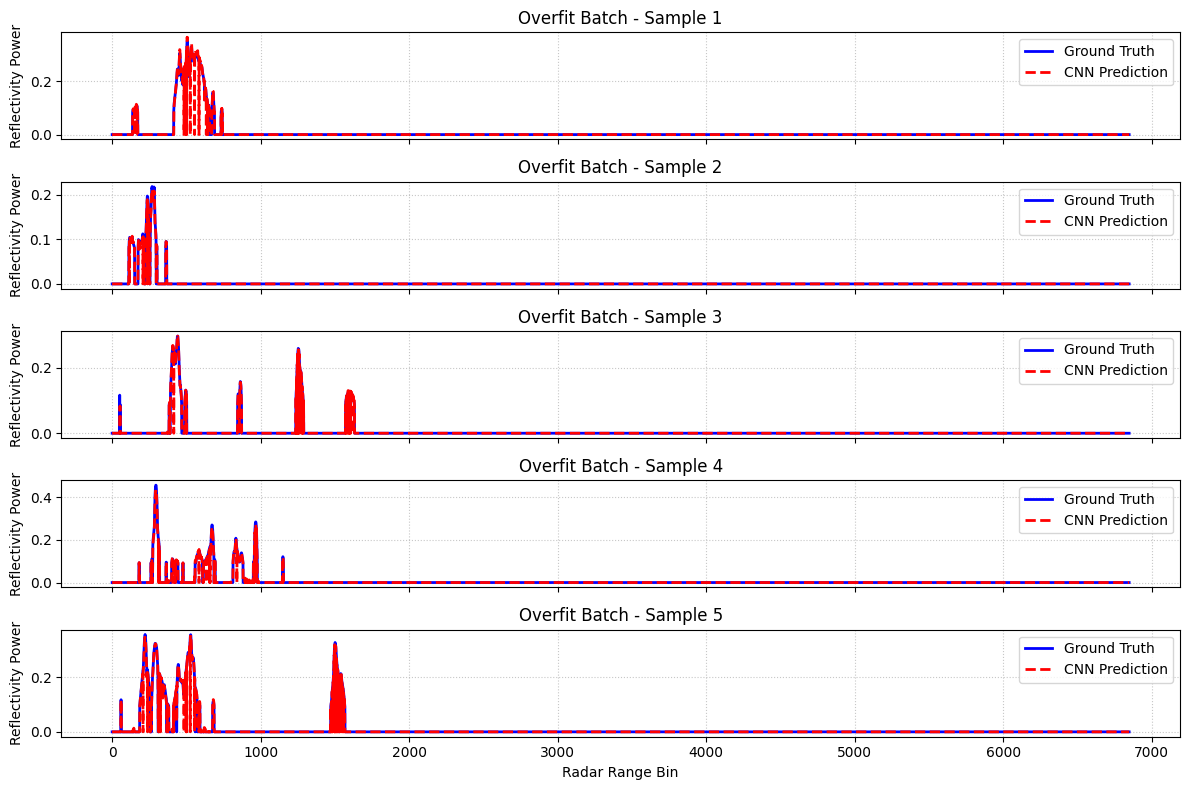

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set the model to evaluation mode (Crucial for inference!)
model.eval()

# 2. Run the forward pass without tracking gradients (saves memory/time)
with torch.no_grad():
    final_preds = model(overfit_patches)

# 3. Move the data off the GPU and convert to NumPy
preds_np = final_preds.cpu().numpy()
labels_np = overfit_labels.cpu().numpy()

# 4. Set up a Matplotlib figure to plot 3 different examples from the batch
num_examples = 5
fig, axes = plt.subplots(num_examples, 1, figsize=(12, 8), sharex=True)

for i in range(num_examples):
    ax = axes[i]
    
    # Plot Ground Truth in Blue
    ax.plot(labels_np[i], label="Ground Truth", color='blue', linewidth=2)
    
    # Plot Prediction in Red (Dashed so you can see the blue underneath)
    ax.plot(preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f"Overfit Batch - Sample {i+1}")
    ax.set_ylabel("Reflectivity Power")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

# Format the bottom X-axis
axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

Epoch [20/20] | Train Loss: 0.00746 | Valid Loss: 0.01124


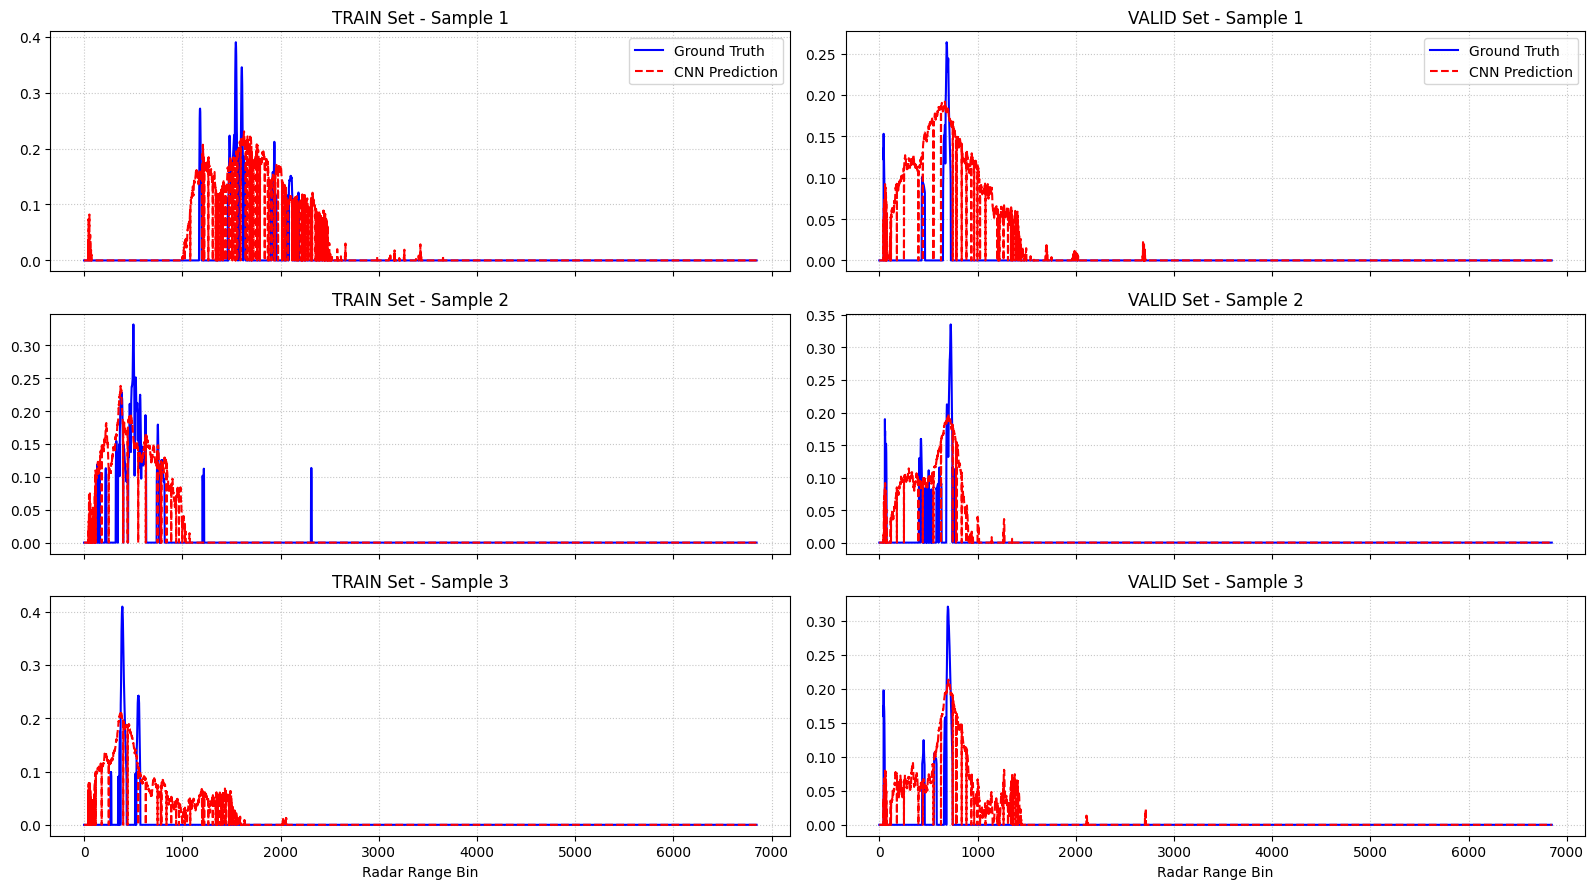

Training Complete!


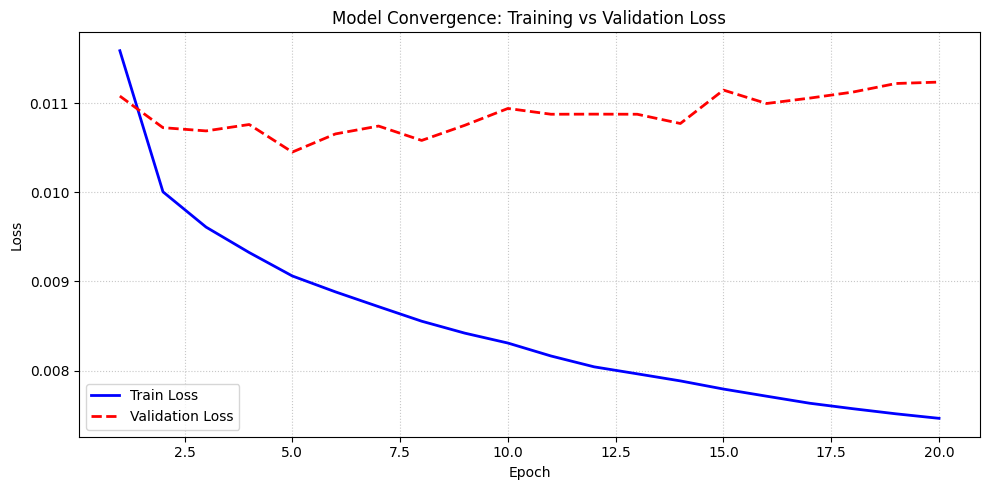

In [9]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import IPython.display as display

# ==========================================
# 1. CHRONOLOGICAL DATASET SPLITTING (BY FRAME)
# ==========================================
# We must split by full 360-degree sweeps, not by individual azimuths
azimuths_per_frame = 400 # Adjust if your Boreas extraction uses a different number
total_frames = len(dataset) // azimuths_per_frame

train_frames = int(0.70 * total_frames) 
valid_frames = int(0.15 * total_frames) 
test_frames = total_frames - train_frames - valid_frames 

# Calculate exact index cutoffs
train_end_idx = train_frames * azimuths_per_frame
valid_end_idx = train_end_idx + (valid_frames * azimuths_per_frame)

# Create chronological subsets that slice cleanly between frames
train_dataset = Subset(dataset, range(0, train_end_idx))
valid_dataset = Subset(dataset, range(train_end_idx, valid_end_idx))

# The test set takes the rest (should naturally be a multiple of azimuths_per_frame)
test_dataset = Subset(dataset, range(valid_end_idx, len(dataset)))

print(f"Total Frames: {total_frames}")
print(f"Frame Split -> Train: {train_frames} | Valid: {valid_frames} | Test: {test_frames}")
print(f"Patch Split -> Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

# Create DataLoaders (Remember to use your worker_init_fn if using multiple workers!)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 2. MODEL & HYPERPARAMETER SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RadarTranslatorCNN(input_size=50, output_bins=num_radar_bins).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = DynamicWeightedMSE(k=1.0, max_weight=500.0)
torch.manual_seed(1000)

num_epochs = 20
plot_every_n_epochs = 1  
samples_to_plot = 3      

# Arrays to track loss over time for the final plot
history_train_loss = []
history_valid_loss = []

# ==========================================
# 2.5 GRAB FIXED BATCHES FOR PLOTTING
# ==========================================
# We grab these once so we can watch the exact same waveforms evolve over time!
fixed_train_patches, fixed_train_labels = next(iter(train_loader))
fixed_valid_patches, fixed_valid_labels = next(iter(valid_loader))

fixed_train_patches = fixed_train_patches.to(device)
fixed_valid_patches = fixed_valid_patches.to(device)

fixed_train_labels_np = fixed_train_labels.numpy()
fixed_valid_labels_np = fixed_valid_labels.numpy()

# ==========================================
# 3. THE TRAINING & VALIDATION LOOP
# ==========================================
print("Starting Full Training with Side-by-Side Monitoring...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0.0
    
    for patches, labels in train_loader:
        patches, labels = patches.to(device), labels.to(device)
        
        optimizer.zero_grad()
        predictions = model(patches)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    
    # --- VALIDATION & PLOTTING PHASE ---
    if (epoch + 1) % plot_every_n_epochs == 0 or epoch == 0:
        model.eval() # Turn off Dropout!
        valid_loss = 0.0
        
        # Calculate full validation loss
        with torch.no_grad():
            for val_patches, val_labels in valid_loader:
                val_patches, val_labels = val_patches.to(device), val_labels.to(device)
                val_preds = model(val_patches)
                batch_loss = criterion(val_preds, val_labels)
                valid_loss += batch_loss.item()
                
        avg_valid_loss = valid_loss / len(valid_loader)
        history_valid_loss.append(avg_valid_loss)
        
        # --- PLOT THE RESULTS ---
        with torch.no_grad():
            train_preds_np = model(fixed_train_patches).cpu().numpy()
            valid_preds_np = model(fixed_valid_patches).cpu().numpy()
            
        display.clear_output(wait=True) 
        
        # Create a 2-column grid: [Rows = samples_to_plot, Cols = 2]
        fig, axes = plt.subplots(samples_to_plot, 2, figsize=(16, 3 * samples_to_plot), sharex=True)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Valid Loss: {avg_valid_loss:.5f}")
        
        # Safety catch in case you only plot 1 sample (forces it into a 2D array format)
        if samples_to_plot == 1: axes = np.expand_dims(axes, axis=0)
            
        for i in range(samples_to_plot):
            # Left Column: TRAINING
            ax_train = axes[i, 0]
            ax_train.plot(fixed_train_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_train.plot(train_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_train.set_title(f"TRAIN Set - Sample {i+1}")
            ax_train.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_train.legend()

            # Right Column: VALIDATION
            ax_valid = axes[i, 1]
            ax_valid.plot(fixed_valid_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_valid.plot(valid_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_valid.set_title(f"VALID Set - Sample {i+1}")
            ax_valid.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_valid.legend()
            
        axes[-1, 0].set_xlabel("Radar Range Bin")
        axes[-1, 1].set_xlabel("Radar Range Bin")
        plt.tight_layout()
        plt.show()

print("Training Complete!")

# ==========================================
# 4. FINAL LOSS CURVE PLOT
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), history_train_loss, label='Train Loss', color='blue', linewidth=2)

# If plotting validation every N epochs, adjust the x-axis for validation loss
val_x_axis = [i for i in range(1, num_epochs + 1) if i % plot_every_n_epochs == 0 or i == 1]
plt.plot(val_x_axis, history_valid_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)

plt.title("Model Convergence: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 1. SAVE THE CURRENT MODEL
# ==========================================
save_path = "model_weights/baseline_filtered_CNN.pth"
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to model_weights/baseline_filtered_CNN.pth


Running inference on the test set...
Average Test Loss: 0.010831
Successfully reconstructed 22 full Polar Radar frames!
Polar array shape: (22, 400, 6848)


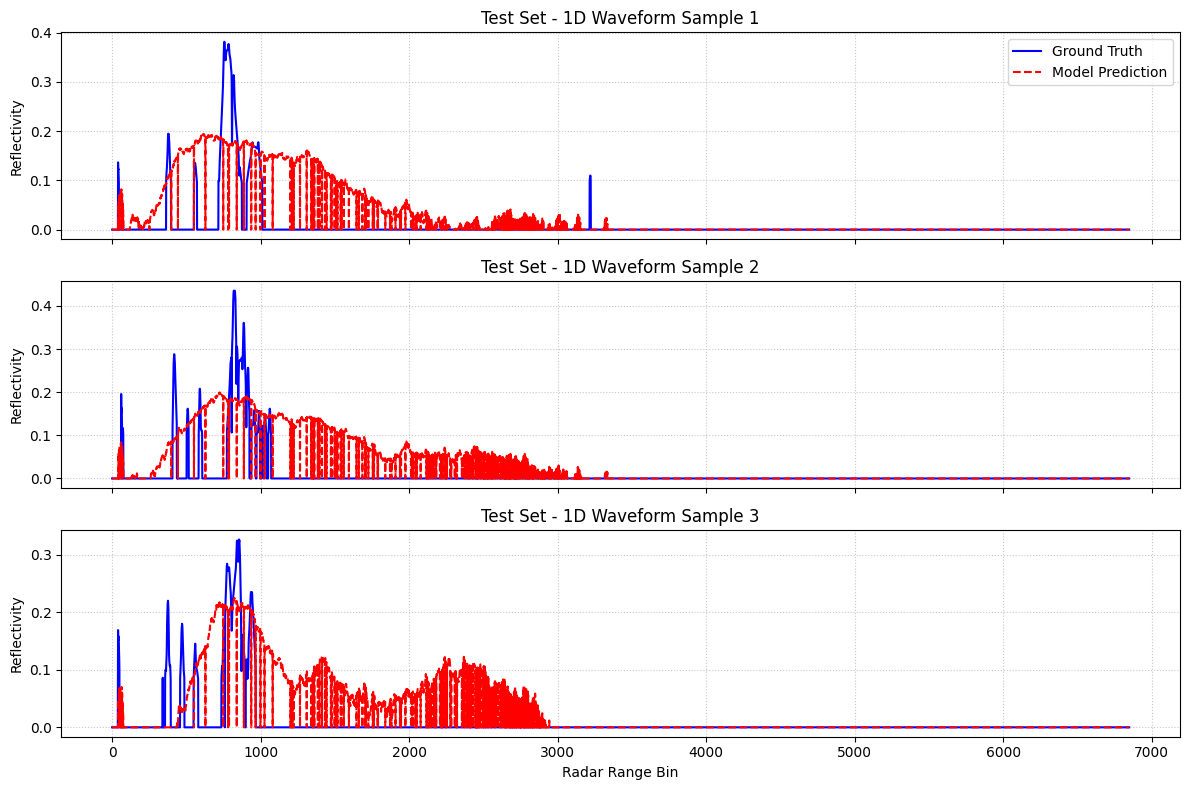

In [11]:
# ==========================================
# 2. RUN INFERENCE ON THE ENTIRE TEST SET
# ==========================================
print("Running inference on the test set...")
model.eval()

all_test_preds = []
all_test_labels = []
test_loss = 0.0

with torch.no_grad():
    for patches, labels in test_loader:
        patches = patches.to(device)
        
        # --- PREDICTION ---
        # If using the OLD single-head model:
        preds = model(patches)
        
        # If using the NEW Two-Headed model, uncomment this:
        # prob_preds, int_preds = model(patches)
        # preds = prob_preds * int_preds 
        
        # Calculate test loss (using whatever criterion you defined)
        batch_loss = criterion(preds, labels.to(device))
        test_loss += batch_loss.item()
        
        # Move back to CPU and store
        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.numpy())

avg_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {avg_test_loss:.6f}")

# Concatenate into massive flat arrays of shape (Total_Samples, 6848)
all_test_preds_np = np.concatenate(all_test_preds, axis=0)
all_test_labels_np = np.concatenate(all_test_labels, axis=0)

# ==========================================
# 3. RECONSTRUCT THE FULL POLAR FRAMES
# ==========================================
# Assuming exactly 400 azimuths per frame based on the Boreas dataset
azimuths_per_frame = 400

# Calculate how many full frames we have (drop any weird partial remainders)
num_full_frames = all_test_preds_np.shape[0] // azimuths_per_frame

# Reshape from (N, 6848) to (Frames, 400, 6848)
polar_preds = all_test_preds_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)
polar_labels = all_test_labels_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)

print(f"Successfully reconstructed {num_full_frames} full Polar Radar frames!")
print(f"Polar array shape: {polar_preds.shape}")

# ==========================================
# 4. PLOT 1D WAVEFORM EXAMPLES
# ==========================================
samples_to_plot = 3
fig, axes = plt.subplots(samples_to_plot, 1, figsize=(12, 8), sharex=True)

for i in range(samples_to_plot):
    ax = axes[i]
    ax.plot(all_test_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax.plot(all_test_preds_np[i], label="Model Prediction", color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Test Set - 1D Waveform Sample {i+1}")
    ax.set_ylabel("Reflectivity")
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0: ax.legend(loc="upper right")

axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()

In [12]:
import torch.nn as nn
import torch

class RadarTranslatorMLP(nn.Module):
    def __init__(self, input_size=50, output_bins=6848):
        super().__init__()
        
        # 50x50 patch = 2500 input features
        flattened_size = input_size * input_size 
        
        self.network = nn.Sequential(
            # Flatten the [Batch, 1, 50, 50] to [Batch, 2500]
            nn.Flatten(),
            
            # Layer 1: The Global Mixer
            nn.Linear(flattened_size, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.3),
            
            # Layer 2: Feature Expansion
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=0.3),
            
            # Layer 3: Output Projection
            nn.Linear(2048, output_bins),
            
            # --- THE SIGMOID CAP ---
            # Forces every single output bin to be strictly between 0.0 and 1.0
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.network(x)

Epoch [20/20] | Train Loss: 0.00595 | Valid Loss: 0.01138


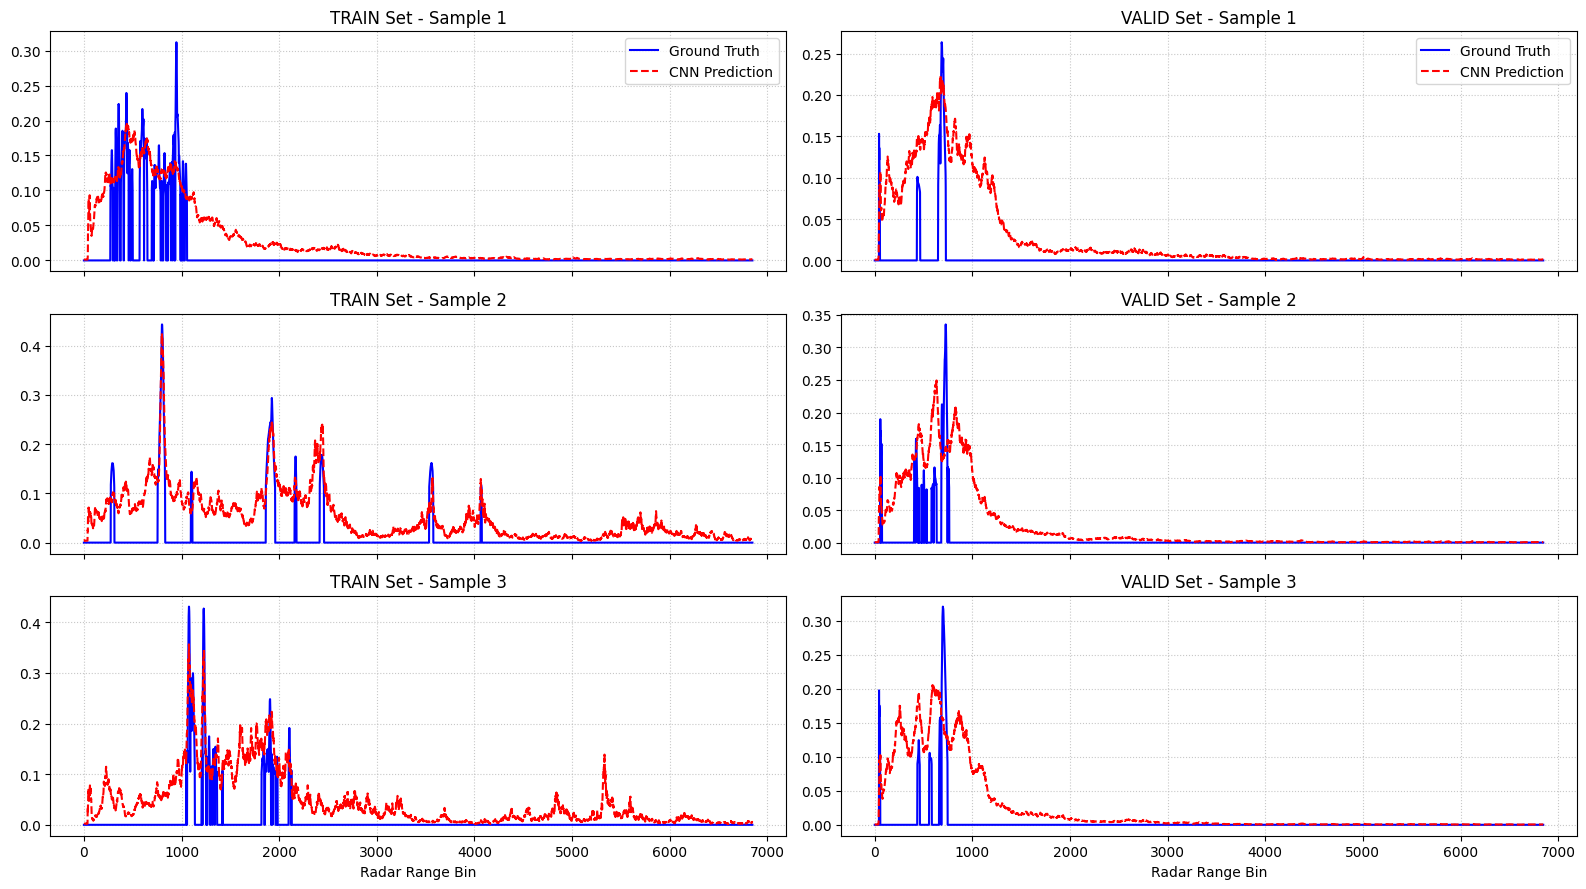

Training Complete!


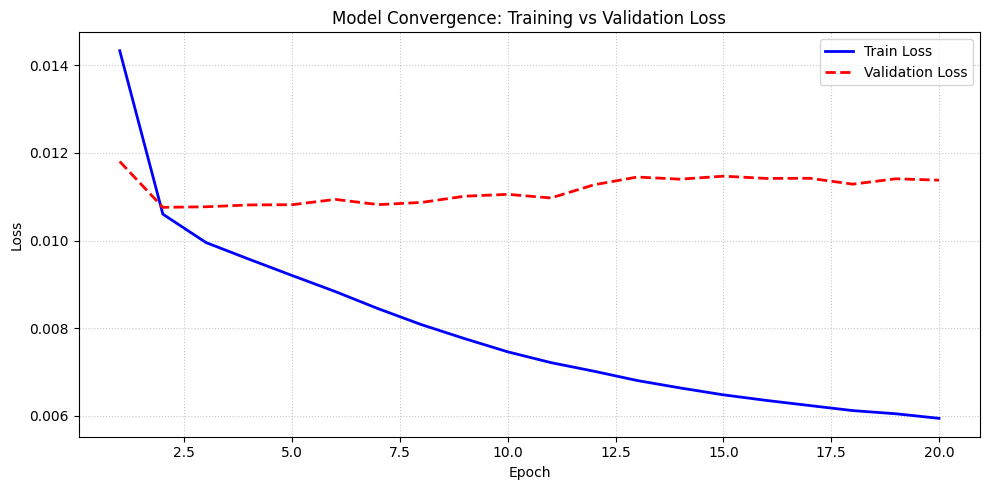

In [13]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import IPython.display as display

# ==========================================
# 1. CHRONOLOGICAL DATASET SPLITTING (BY FRAME)
# ==========================================
# We must split by full 360-degree sweeps, not by individual azimuths
azimuths_per_frame = 400 # Adjust if your Boreas extraction uses a different number
total_frames = len(dataset) // azimuths_per_frame

train_frames = int(0.70 * total_frames) 
valid_frames = int(0.15 * total_frames) 
test_frames = total_frames - train_frames - valid_frames 

# Calculate exact index cutoffs
train_end_idx = train_frames * azimuths_per_frame
valid_end_idx = train_end_idx + (valid_frames * azimuths_per_frame)

# Create chronological subsets that slice cleanly between frames
train_dataset = Subset(dataset, range(0, train_end_idx))
valid_dataset = Subset(dataset, range(train_end_idx, valid_end_idx))

# The test set takes the rest (should naturally be a multiple of azimuths_per_frame)
test_dataset = Subset(dataset, range(valid_end_idx, len(dataset)))

print(f"Total Frames: {total_frames}")
print(f"Frame Split -> Train: {train_frames} | Valid: {valid_frames} | Test: {test_frames}")
print(f"Patch Split -> Train: {len(train_dataset)} | Valid: {len(valid_dataset)} | Test: {len(test_dataset)}")

# Create DataLoaders (Remember to use your worker_init_fn if using multiple workers!)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==========================================
# 2. MODEL & HYPERPARAMETER SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RadarTranslatorMLP(input_size=50, output_bins=num_radar_bins).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = DynamicWeightedMSE(k=1.0, max_weight=500.0)

num_epochs = 20
plot_every_n_epochs = 1  
samples_to_plot = 3      

# Arrays to track loss over time for the final plot
history_train_loss = []
history_valid_loss = []

# ==========================================
# 2.5 GRAB FIXED BATCHES FOR PLOTTING
# ==========================================
# We grab these once so we can watch the exact same waveforms evolve over time!
fixed_train_patches, fixed_train_labels = next(iter(train_loader))
fixed_valid_patches, fixed_valid_labels = next(iter(valid_loader))

fixed_train_patches = fixed_train_patches.to(device)
fixed_valid_patches = fixed_valid_patches.to(device)

fixed_train_labels_np = fixed_train_labels.numpy()
fixed_valid_labels_np = fixed_valid_labels.numpy()

# ==========================================
# 3. THE TRAINING & VALIDATION LOOP
# ==========================================
print("Starting Full Training with Side-by-Side Monitoring...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0.0
    
    for patches, labels in train_loader:
        patches, labels = patches.to(device), labels.to(device)
        
        optimizer.zero_grad()
        predictions = model(patches)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    history_train_loss.append(avg_train_loss)
    
    # --- VALIDATION & PLOTTING PHASE ---
    if (epoch + 1) % plot_every_n_epochs == 0 or epoch == 0:
        model.eval() # Turn off Dropout!
        valid_loss = 0.0
        
        # Calculate full validation loss
        with torch.no_grad():
            for val_patches, val_labels in valid_loader:
                val_patches, val_labels = val_patches.to(device), val_labels.to(device)
                val_preds = model(val_patches)
                batch_loss = criterion(val_preds, val_labels)
                valid_loss += batch_loss.item()
                
        avg_valid_loss = valid_loss / len(valid_loader)
        history_valid_loss.append(avg_valid_loss)
        
        # --- PLOT THE RESULTS ---
        with torch.no_grad():
            train_preds_np = model(fixed_train_patches).cpu().numpy()
            valid_preds_np = model(fixed_valid_patches).cpu().numpy()
            
        display.clear_output(wait=True) 
        
        # Create a 2-column grid: [Rows = samples_to_plot, Cols = 2]
        fig, axes = plt.subplots(samples_to_plot, 2, figsize=(16, 3 * samples_to_plot), sharex=True)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Valid Loss: {avg_valid_loss:.5f}")
        
        # Safety catch in case you only plot 1 sample (forces it into a 2D array format)
        if samples_to_plot == 1: axes = np.expand_dims(axes, axis=0)
            
        for i in range(samples_to_plot):
            # Left Column: TRAINING
            ax_train = axes[i, 0]
            ax_train.plot(fixed_train_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_train.plot(train_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_train.set_title(f"TRAIN Set - Sample {i+1}")
            ax_train.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_train.legend()

            # Right Column: VALIDATION
            ax_valid = axes[i, 1]
            ax_valid.plot(fixed_valid_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
            ax_valid.plot(valid_preds_np[i], label="CNN Prediction", color='red', linestyle='--', linewidth=1.5)
            ax_valid.set_title(f"VALID Set - Sample {i+1}")
            ax_valid.grid(True, linestyle=':', alpha=0.7)
            if i == 0: ax_valid.legend()
            
        axes[-1, 0].set_xlabel("Radar Range Bin")
        axes[-1, 1].set_xlabel("Radar Range Bin")
        plt.tight_layout()
        plt.show()

print("Training Complete!")

# ==========================================
# 4. FINAL LOSS CURVE PLOT
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), history_train_loss, label='Train Loss', color='blue', linewidth=2)

# If plotting validation every N epochs, adjust the x-axis for validation loss
val_x_axis = [i for i in range(1, num_epochs + 1) if i % plot_every_n_epochs == 0 or i == 1]
plt.plot(val_x_axis, history_valid_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)

plt.title("Model Convergence: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# 1. SAVE THE CURRENT MODEL
# ==========================================
save_path = "model_weights/baseline_filtered_MLP.pth"
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to model_weights/baseline_filtered_MLP.pth


Running inference on the test set...
Average Test Loss: 0.010948
Successfully reconstructed 22 full Polar Radar frames!
Polar array shape: (22, 400, 6848)


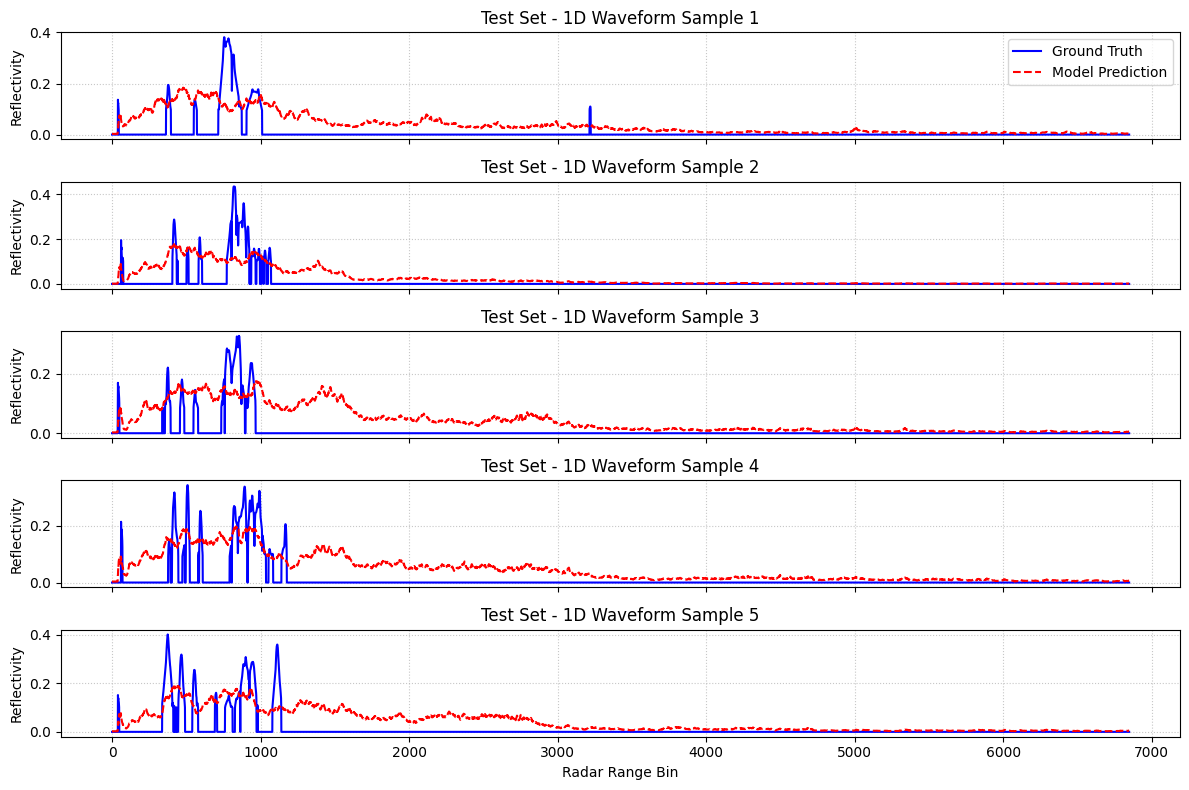

In [16]:
# ==========================================
# 2. RUN INFERENCE ON THE ENTIRE TEST SET
# ==========================================
print("Running inference on the test set...")
model.eval()

all_test_preds = []
all_test_labels = []
test_loss = 0.0

with torch.no_grad():
    for patches, labels in test_loader:
        patches = patches.to(device)
        
        # --- PREDICTION ---
        # If using the OLD single-head model:
        preds = model(patches)
        
        # If using the NEW Two-Headed model, uncomment this:
        # prob_preds, int_preds = model(patches)
        # preds = prob_preds * int_preds 
        
        # Calculate test loss (using whatever criterion you defined)
        batch_loss = criterion(preds, labels.to(device))
        test_loss += batch_loss.item()
        
        # Move back to CPU and store
        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.numpy())

avg_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {avg_test_loss:.6f}")

# Concatenate into massive flat arrays of shape (Total_Samples, 6848)
all_test_preds_np = np.concatenate(all_test_preds, axis=0)
all_test_labels_np = np.concatenate(all_test_labels, axis=0)

# ==========================================
# 3. RECONSTRUCT THE FULL POLAR FRAMES
# ==========================================
# Assuming exactly 400 azimuths per frame based on the Boreas dataset
azimuths_per_frame = 400

# Calculate how many full frames we have (drop any weird partial remainders)
num_full_frames = all_test_preds_np.shape[0] // azimuths_per_frame

# Reshape from (N, 6848) to (Frames, 400, 6848)
polar_preds = all_test_preds_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)
polar_labels = all_test_labels_np[:num_full_frames * azimuths_per_frame].reshape(num_full_frames, azimuths_per_frame, -1)

print(f"Successfully reconstructed {num_full_frames} full Polar Radar frames!")
print(f"Polar array shape: {polar_preds.shape}")

# ==========================================
# 4. PLOT 1D WAVEFORM EXAMPLES
# ==========================================
samples_to_plot = 5
fig, axes = plt.subplots(samples_to_plot, 1, figsize=(12, 8), sharex=True)

for i in range(samples_to_plot):
    ax = axes[i]
    ax.plot(all_test_labels_np[i], label="Ground Truth", color='blue', linewidth=1.5)
    ax.plot(all_test_preds_np[i], label="Model Prediction", color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"Test Set - 1D Waveform Sample {i+1}")
    ax.set_ylabel("Reflectivity")
    ax.grid(True, linestyle=':', alpha=0.7)
    if i == 0: ax.legend(loc="upper right")

axes[-1].set_xlabel("Radar Range Bin")
plt.tight_layout()
plt.show()